## Overview and Explanation
### Overview
This analysis examines the player-driven currency market in Path of Exile using publicly available data collected from poe.ninja, a community-maintained website that aggregates and archives market information for the game. Poe.ninja compiles price estimates and historical trends by analyzing active trade listings, providing a statistical snapshot of the in-game economy rather than a record of completed transactions. Using this data, standard financial market concepts—such as liquidity, price movement, volatility, and bid–ask spreads—are applied to a nontraditional, virtual economy. Currency price data were processed to identify highly liquid and thinly traded assets, measure short-term price changes, and explore relationships between market participation and price behavior, with both aggregate metrics and short-term price trajectories used to contextualize observed market dynamics.
### Explanation
Path of Exile features a fully player-driven market in which prices are determined by player listings rather than by the game itself. Instead of a centralized auction house, players post listings indicating the exchange rates at which they are willing to trade items or currencies, and other players initiate trades directly. This creates a decentralized market structure analogous to real financial markets, where buy-side (bid) prices reflect the cost required to acquire a currency and sell-side (ask) prices reflect the proceeds received when selling it. Because buy and sell listings are created independently, these prices often differ, producing bid–ask spreads that reflect market friction and liquidity. Markets with many active listings tend to exhibit smoother price adjustment, while thinly traded markets often display wider spreads and greater price instability.\
Path of Exile does not use a single universal currency such as gold, instead operating as a barter-based economy composed of many itemized currencies, each with intrinsic in-game functionality related to crafting and item modification. Over time, the player community has converged on using certain high-demand crafting items—most notably Chaos Orbs and Divine Orbs—as de facto currencies, even though they were not designed for this role. Through widespread acceptance and consistent demand, these items serve as common units of account, allowing prices of other items and currencies to be quoted relative to them. This emergent monetary system enables meaningful economic analysis despite the absence of a formal currency, as exchange rates fluctuate based on supply, demand, and player behavior in ways that closely resemble real-world financial markets.

In [6]:
import json
import requests
import pandas as pd

### API Discovery
This section is preserved for posterities sake. It entails some of the processes I went through to familiarize myself with this undocumented API.
All the code has been commented out to enable easy sequential execution of the notebook.

In [7]:
# # Analysis to see if there are any redundant fields between pay and receive
# def compare_pay_receive(df, prefix_pay="pay_", prefix_recv="receive_"):
#     results = []

#     pay_cols = [c for c in df.columns if c.startswith(prefix_pay)]
#     recv_cols = [c for c in df.columns if c.startswith(prefix_recv)]

#     # Match columns by suffix (e.g. value, listing_count)
#     common_suffixes = set(
#         c[len(prefix_pay):] for c in pay_cols
#     ) & set(
#         c[len(prefix_recv):] for c in recv_cols
#     )

#     for suffix in sorted(common_suffixes):
#         pay_col = prefix_pay + suffix
#         recv_col = prefix_recv + suffix

#         # Compare, ignoring rows where both are NaN
#         equal = df[pay_col].equals(df[recv_col])

#         results.append({
#             "field": suffix,
#             "identical": equal,
#             "pay_col": pay_col,
#             "receive_col": recv_col
#         })

#     return pd.DataFrame(results)

# comparison = compare_pay_receive(currency_df)
# print(comparison)


In [8]:
# print(currency_df.sort_values(by="pay_data_point_count", ascending=False).head(10)[['currencyTypeName', 'pay_data_point_count']])
# print(currency_df.sort_values(by="receive_data_point_count", ascending=False).head(10)[['currencyTypeName', 'receive_data_point_count']])
# unique_a = currency_df['pay_data_point_count'].unique()
# print(f"Unique values in column 'pay_data_point_count': {len(unique_a)}")
# # Okay data_point_counts represent items with variation, useless for static items like currency

In [9]:
# print(currency_df.columns)
# print(currency_df[['currencyTypeName', 'pay_value', 'receive_value']])

### Dynamic Output
Functions for dynamically assessing correlation pairs responsible for creating human-readable output

In [10]:
# Function for interpreting correlation strength and direction
def interpret_correlation(r):
    abs_r = abs(r)

    if abs_r < 0.1:
        strength = "very weak"
    elif abs_r < 0.3:
        strength = "weak"
    elif abs_r < 0.5:
        strength = "moderate"
    elif abs_r < 0.7:
        strength = "strong"
    else:
        strength = "very strong"

    direction = (
        "positive" if r > 0 else
        "negative" if r < 0 else
        "no"
    )

    return strength, direction

# Dictionary of string for correlation interpretations (liquidity + volatility, liquidity + spread)
correlation_explanations = {
    "liquidity_volatility": {
        "positive": "More liquid currencies tend to exhibit greater volatility.",
        "negative": "More liquid currencies tend to exhibit lower volatility.",
        "none": "No clear relationship is observed between liquidity and volatility."
    },
    "liquidity_spread": {
        "positive": "More liquid currencies tend to have wider bid–ask spreads.",
        "negative": "More liquid currencies tend to have tighter bid–ask spreads.",
        "none": "Liquidity does not appear to strongly explain bid–ask spread size."
    }
}
# Function for generating correlation report
def describe_correlation(name, r):
    strength, direction = interpret_correlation(r)

    direction_key = direction if strength != "very weak" else "none"
    base = correlation_explanations[name][direction_key]

    return (
        f"The correlation is {strength} ({r:.2f}), "
        f"suggesting that {base.lower()}"
    )


In [11]:
## Provide your API key here for TAs to reproduce your results
API_KEY = "your_api_key_here"


 ### Q0: Write a function to fetch data from the API
 This code section also contains a number of helper functions for the purpose of our analysis.
 This includes:
 - A JSON -> pandas DataFrame converter which also flattens and reduces dimensionality
 - A time series DataFrame creator which creates a row for each recorded day of price fluctuation (For visualization)
 - An augmentation function which calculates and creates various financial columns for our standard DataFrame

In [12]:
import requests
import pandas as pd

def create_currency_df(data):
    # Convert to DataFrame and modify
    currency_df = pd.DataFrame(data['lines'])
    # Gets percent change from sparkline data to reduce dataframe dimensionality
    def get_total_change(sparkline):
        return None if not isinstance(sparkline, dict) else sparkline.get("totalChange")

    currency_df['receive_7d_change_pct'] = currency_df['receiveSparkLine'].apply(get_total_change)
    currency_df['pay_7d_change_pct'] = currency_df['paySparkLine'].apply(get_total_change)

    # Flattens pay/receive dictionaries
    def flatten(d, keys):
        if not isinstance(d, dict):
            return {key: None for key in keys}
        return {key: d.get(key, None) for key in keys}

    pay_keys = ['id', 'league_id', 'pay_currency_id', 'get_currency_id', 'sample_time_utc', 'count', 'value', 'data_point_count', 'includes_secondary', 'listing_count']
    receive_keys = ['id', 'league_id', 'pay_currency_id', 'get_currency_id', 'sample_time_utc', 'count', 'value', 'data_point_count', 'includes_secondary']

    # Create flattened dataframes for pay and receive
    pay_df = pd.DataFrame([flatten(x, pay_keys) for x in currency_df['pay']]).add_prefix('pay_')
    receive_df = pd.DataFrame([flatten(x, receive_keys) for x in currency_df['receive']]).add_prefix('receive_')

    # Recombine dataframes
    currency_df = pd.concat([currency_df.drop(columns=['pay', 'receive']), pay_df, receive_df], axis=1)

    # Drop sparkline columns
    currency_df = currency_df.drop(columns=['paySparkLine', 'receiveSparkLine', "lowConfidencePaySparkLine", "lowConfidenceReceiveSparkLine"])
    return currency_df

# Function for creating time series DataFrame of relative currency price change from sparkline data
def build_time_series(data):
    rows = []
    for row in data['lines']:
        # Retrieve receive sparkline data
        series = row.get('receiveSparkLine', {}).get('data', None)
        # If we didn't get a valid series, skip
        if not isinstance(series, list):
            continue
        # Create a row for every day in the series (value represents % change relative to first day)
        for i, value in enumerate(series):
            rows.append({
                'currencyTypeName': row['currencyTypeName'],
                'day_index': i,
                'value': value
            })
    return pd.DataFrame(rows)

# DataFrame augmentation function for financial analysis of currency data
def augment_currency_df(currency_df):
    # Total number of current listings (buy + sell)
    currency_df['listing_count'] = currency_df['pay_count'] + currency_df['receive_count']
    # Absolute value of 7 day percent changes (for asset volatility analysis)
    currency_df['absolute_receive_7d_change'] = currency_df['receive_7d_change_pct'].abs()
    currency_df['absolute_pay_7d_change'] = currency_df['pay_7d_change_pct'].abs()
    # Create concrete buy and sell price columns
    currency_df['buy_price_chaos'] = currency_df['receive_value']
    currency_df['sell_price_chaos'] = 1 / currency_df['pay_value']
    currency_df['spread_chaos'] = currency_df['sell_price_chaos'] - currency_df['buy_price_chaos']
    currency_df['spread_pct'] = currency_df['spread_chaos'] / currency_df['buy_price_chaos'] * 100
    return currency_df

def fetch_data(endpoint, params, headers=None):
    """
    Fetch data from the given API endpoint with specified parameters.
    
    Args:
        endpoint (str): The API endpoint URL.
        params (dict): Dictionary of query parameters.
        headers (dict): Optional headers for the request.

    Returns:
        dict: JSON response from the API.

    Raises:
        requests.exceptions.RequestException: If the request fails.
    """
    try:
        response = requests.get(endpoint, params=params, headers=headers, timeout=10)
        response.raise_for_status()  # Raise an error for bad responses (4XX, 5XX)
        return response.json()
    except requests.exceptions.RequestException as e:
        print(f"An error occurred: {e}")
        return None
# Example: Replace `example_api_endpoint` with your actual endpoint.
# response = fetch_data("https://api.example.com/data", {"param1": "value1"}, headers={"Authorization": f"Bearer {API_KEY}"})
# print(response)


 ### Q1: Market Liquidity and Activity Analysis
 Generic overview of market information.
 Covers topics such as:
 - Most/Least liquid assets
 - Most/Least expensive assets

In [13]:
def answer_question_1():
    # API request parameters
    league = "Keepers"  # or your current league name
    endpoint = "https://poe.ninja/api/data/currencyoverview"
    params = {"league": league, "type": "Currency"}
    data = fetch_data(endpoint, params)

    if data:
        # If we haven't already created a dataframe representation
        currency_df = create_currency_df(data)
        currency_df = augment_currency_df(currency_df)
        # Market Liquidity and Activity analysis
        # Currency with most listings
        print("Most liquid currency assets (Top 5 by listing count):")
        print(currency_df.sort_values(by='listing_count', ascending=False)[['currencyTypeName', 'listing_count']].head(5))
        # Currency with least listings
        print("Least liquid currency assets (Top 5 by listing count):")
        print(currency_df.sort_values(by='listing_count', ascending=True)[['currencyTypeName', 'listing_count']].head(5))
        # General overview of 5 most expensive and 5 cheapest currencies by chaos equivalent
        print("Most expensive currencies by chaos equivalent (Top 5):")
        print(currency_df.sort_values(by='chaosEquivalent', ascending=False)[['currencyTypeName', 'chaosEquivalent']].head(5))
        print("Least expensive currencies by chaos equivalent (Top 5):")
        print(currency_df.sort_values(by='chaosEquivalent', ascending=True)[['currencyTypeName', 'chaosEquivalent']].head(5))

        

answer_question_1()


Most liquid currency assets (Top 5 by listing count):
     currencyTypeName  listing_count
54      Orb of Fusing          100.0
56  Orb of Alteration           93.0
58      Chromatic Orb           87.0
5          Divine Orb           87.0
63     Jeweller's Orb           70.0
Least liquid currency assets (Top 5 by listing count):
          currencyTypeName  listing_count
8               Sacred Orb           13.0
15             Ancient Orb           13.0
1          Reflecting Mist           14.0
44    Glassblower's Bauble           14.0
57  Blacksmith's Whetstone           16.0
Most expensive currencies by chaos equivalent (Top 5):
     currencyTypeName  chaosEquivalent
0  Mirror of Kalandra         250000.0
1     Reflecting Mist           4878.0
2      Fracturing Orb            804.0
3       Tempering Orb            407.4
4     Orb of Conflict            348.4
Least expensive currencies by chaos equivalent (Top 5):
                 currencyTypeName  chaosEquivalent
70    Wild Crystallis

 ### Q2: Directional Price Movement Analysis
Here we are doing a basic price movement analysis based off the last week of data.
We are analyzing:
- Biggest gaining currency (Bid + Ask)
- Biggest losing currency (Bid + Ask)
- Most volatile currency (Bid + Ask)

In [14]:
def answer_question_2():
    # API request parameters
    league = "Keepers"  # or your current league name
    endpoint = "https://poe.ninja/api/data/currencyoverview"
    params = {"league": league, "type": "Currency"}
    data = fetch_data(endpoint, params)

    if data:
        # If we haven't already created a dataframe representation
        currency_df = create_currency_df(data)
        currency_df = augment_currency_df(currency_df)
        # Directional price movement analysis   
        # Sell side
        print(f'Top sell-side (ask) price gainers (7-day % change):')
        print(currency_df.sort_values(by='receive_7d_change_pct', ascending=False)[['currencyTypeName', 'receive_7d_change_pct']].head(5))
        print(f'Top sell-side (ask) price losers (7-day % change):')
        print(currency_df.sort_values(by='receive_7d_change_pct', ascending=True)[['currencyTypeName', 'receive_7d_change_pct']].head(5))
        # Buy side
        print(f'Top buy-side (bid) price gainers (7-day % change):')
        print(currency_df.sort_values(by='pay_7d_change_pct', ascending=False)[['currencyTypeName', 'pay_7d_change_pct']].head(5))
        # Currencies with largest decrease over last 7 days
        print(f'Top buy-side (bid) price losers (7-day % change):')
        print(currency_df.sort_values(by='pay_7d_change_pct', ascending=True)[['currencyTypeName', 'pay_7d_change_pct']].head(5))

        # Volatility analysis
        print("Most volatile currencies (sell-side, 7-day magnitude):")
        print(currency_df.sort_values(by='absolute_receive_7d_change', ascending=False)[['currencyTypeName', 'receive_7d_change_pct']].head(5))
        print("Most volatile currencies (buy-side, 7-day magnitude):")
        print(currency_df.sort_values(by='absolute_pay_7d_change', ascending=False)[['currencyTypeName', 'pay_7d_change_pct']].head(5))

        

answer_question_2()


Top sell-side (ask) price gainers (7-day % change):
                   currencyTypeName  receive_7d_change_pct
10  Maven's Chisel of Proliferation                 2735.0
12                 Fertile Catalyst                 1200.0
9         Maven's Chisel of Avarice                 1018.0
65                    Portal Scroll                  115.6
24       Explorer's Scouting Report                  100.0
Top sell-side (ask) price losers (7-day % change):
             currencyTypeName  receive_7d_change_pct
32         Prismatic Catalyst                 -87.50
36  Delirious Scouting Report                 -87.34
7        Foulborn Exalted Orb                 -85.71
41         Foulborn Regal Orb                 -80.00
34          Unstable Catalyst                 -80.00
Top buy-side (bid) price gainers (7-day % change):
         currencyTypeName  pay_7d_change_pct
0      Mirror of Kalandra             150.00
5              Divine Orb              21.75
45               Vaal Orb              

 ### Q3: Correlation Analysis of Liquidity
Here we analyze both the spread and volatilities' correlation to liquidity to mimic real world preliminary financial analysis.

In [15]:
def answer_question_3():
    # API request parameters
    league = "Keepers"  # or your current league name
    endpoint = "https://poe.ninja/api/data/currencyoverview"
    params = {"league": league, "type": "Currency"}
    data = fetch_data(endpoint, params)

    if data:
        # If we haven't already created a dataframe representation
        currency_df = create_currency_df(data)
        currency_df = augment_currency_df(currency_df)
        # Analyzing correlation liquidity to basic financial metrics
        liquidity_spread = currency_df['listing_count'].corr(currency_df['spread_pct'])
        liquidity_volatility = currency_df['listing_count'].corr(currency_df['absolute_receive_7d_change'])
        # Calling some functions for dynamic report generation
        print(describe_correlation("liquidity_volatility", liquidity_volatility))
        print(describe_correlation("liquidity_spread", liquidity_spread))

        

answer_question_3()


The correlation is weak (-0.27), suggesting that more liquid currencies tend to exhibit lower volatility.
The correlation is weak (0.12), suggesting that more liquid currencies tend to have wider bid–ask spreads.


 ### Q4: Optional - Visualizing data
 Here I chose to visualize the relative chance in prices for the five most volatile assets (Bid price)

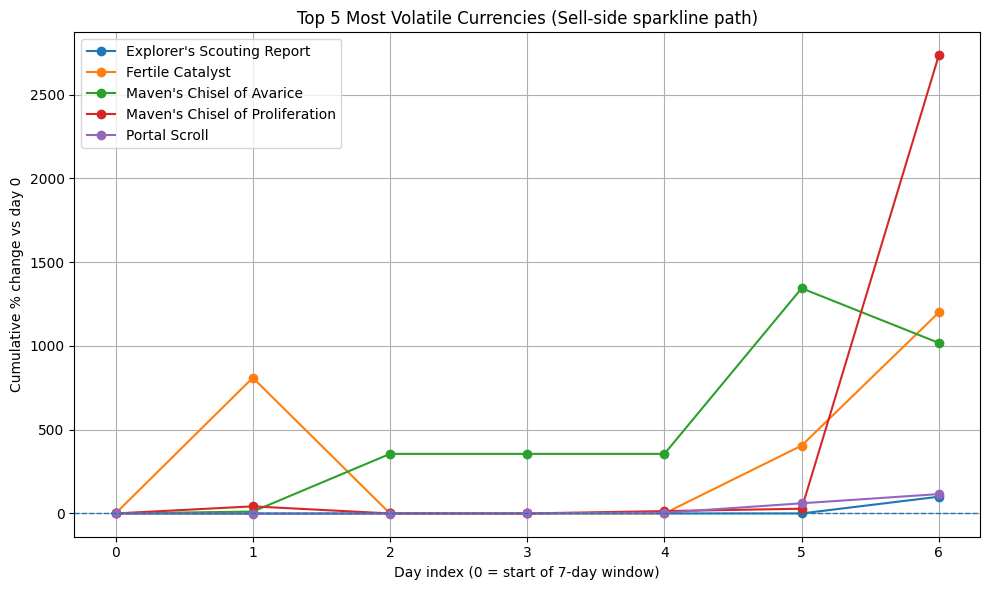

In [16]:
import matplotlib.pyplot as plt

def visualize_question_4():
    league = "Keepers"  # or your current league name
    endpoint = "https://poe.ninja/api/data/currencyoverview"
    params = {"league": league, "type": "Currency"}
    data = fetch_data(endpoint, params)

    if data:
        # Creating and augmenting general purpose currency data frame
        currency_df = create_currency_df(data)
        currency_df = augment_currency_df(currency_df)
        # Creating time series df that holds sparkline data of all currency price fluctuations (7 rows per currency, 1 per day)
        time_series_df = build_time_series(data)
        # Calculate most volatile currencies based on absolute 7-day change (list of top 5 most volatile currency names)
        most_volatile_currencies = currency_df.sort_values(by='absolute_receive_7d_change', ascending=False)['currencyTypeName'].head(5).tolist()
        # Filter time series data to only include most volatile currencies
        filtered_time_series = time_series_df[time_series_df['currencyTypeName'].isin(most_volatile_currencies)]

        # Plotting
        plt.figure(figsize=(10, 6))

        for cid, grp in filtered_time_series.groupby("currencyTypeName"):
            grp = grp.sort_values("day_index")
            plt.plot(grp["day_index"], grp["value"], marker="o", label=cid)

        plt.axhline(0, linestyle="--", linewidth=1)
        plt.xlabel("Day index (0 = start of 7-day window)")
        plt.ylabel("Cumulative % change vs day 0")
        plt.title("Top 5 Most Volatile Currencies (Sell-side sparkline path)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        
        

visualize_question_4()
